# COMP5329 — Deep Learning

**Tutorial — Graph Convolutional Networks**

**Semester 1, 2026**

### Learning Objectives
By the end of this tutorial you will be able to:
1. Represent a graph as an adjacency matrix and a degree matrix.
2. Explain the GCN propagation rule from a **spatial (neighbourhood aggregation)** perspective.
3. Implement a custom `GCNLayer` with `nn.Parameter` weights, manual forward, and autograd backward.
4. Train a 2-layer GCN for **semi-supervised node classification** on the Karate Club graph.
5. Describe how the same learnt embeddings can support **graph classification** and **link prediction**.

---
## §0 — Why Graphs?

Most deep-learning architectures assume **Euclidean** (grid-structured) inputs:
- **Images** → 2-D pixel grids (CNNs exploit fixed neighbourhood and spatial ordering).
- **Sequences** → 1-D timelines (RNNs exploit ordered steps).

Many real-world data sets live on **irregular relational structures**:

| Domain | Nodes | Edges |
|---|---|---|
| Social networks | Users | Friendships |
| Molecules | Atoms | Chemical bonds |
| Knowledge graphs | Entities | Relations |
| Scene understanding | Objects | Spatial relations |

**Why standard CNNs fail on graphs:**
- Each node can have a *different* number of neighbours.
- There is *no natural spatial ordering* among neighbours.

→ We need an architecture that is **permutation-invariant** and handles variable-size neighbourhoods.

---
## §1 — Graph Fundamentals

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

### 1.1 Key Matrices

A graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ with $N$ nodes is described by:

| Symbol | Shape | Meaning |
|---|---|---|
| $A$ | $N \times N$ | **Adjacency matrix** — $A_{ij}=1$ if edge $(i,j)$ exists |
| $D$ | $N \times N$ | **Degree matrix** — diagonal, $D_{ii} = \sum_j A_{ij}$ |
| $\hat{A} = A + I$ | $N \times N$ | Adjacency with **self-loops** |
| $\hat{D}$ | $N \times N$ | Degree matrix of $\hat{A}$ |

**Why self-loops?**
Without $\hat{A}$, the GCN aggregation does *not* include the node itself —
its own feature is discarded at every layer.  Adding $I$ ensures node $i$
is part of its own neighbourhood.

In [2]:
# Load the Zachary Karate Club graph (34 nodes, 78 edges)
G = nx.karate_club_graph()
n = G.number_of_nodes()

A     = nx.to_numpy_array(G)        # (N, N) — raw adjacency
A_hat = A + np.eye(n)               # Â = A + I  (self-loops)
d_hat = A_hat.sum(axis=1)           # degree vector of Â
D_hat = np.diag(d_hat)              # Â's degree matrix

print(f"Nodes: {n},  Edges: {G.number_of_edges()}")
print(f"A_hat[0, :10] = {A_hat[0, :10]}")
print(f"D_hat diagonal (first 6): {np.diag(D_hat)[:6]}")

Nodes: 34,  Edges: 78
A_hat[0, :10] = [1. 4. 5. 3. 3. 3. 3. 2. 2. 0.]
D_hat diagonal (first 6): [43. 30. 34. 19.  9. 15.]


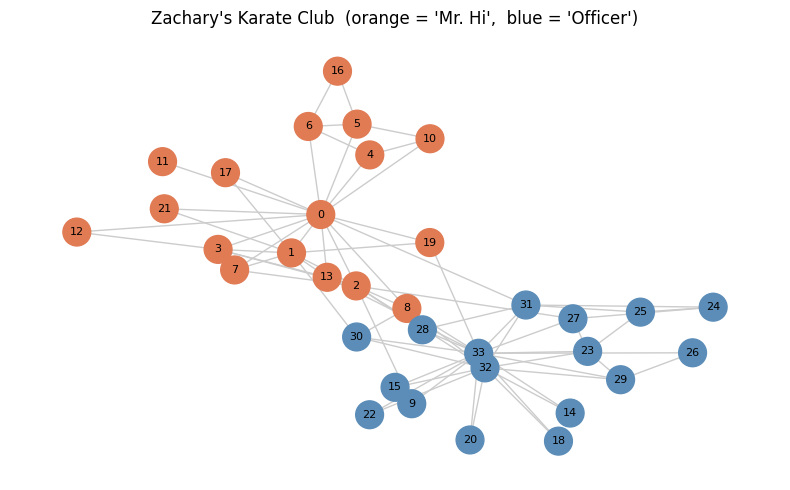

In [3]:
# Visualise the graph — colour nodes by community
community  = nx.get_node_attributes(G, 'club')
node_color = ['#E07B54' if community[i] == 'Mr. Hi' else '#5B8DB8'
              for i in G.nodes()]

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 5))
nx.draw_networkx(G, pos=pos, node_color=node_color, node_size=400,
                 font_size=8, edge_color='#cccccc', with_labels=True)
plt.title("Zachary's Karate Club  (orange = 'Mr. Hi',  blue = 'Officer')")
plt.axis('off')
plt.tight_layout()
plt.show()

---
## §2 — GCN: Spatial Perspective

### 2.1 Neighbourhood Aggregation

The core GCN idea: **each node's new representation aggregates its own
features and its neighbours' features** via a shared learnable weight matrix.

**GCN propagation rule (one layer):**

$$\boxed{H^{(l+1)} = \sigma\!\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}\;H^{(l)}\;W^{(l)}\right)}$$

where:
- $H^{(l)} \in \mathbb{R}^{N \times F_l}$ — node feature matrix at layer $l$
- $W^{(l)} \in \mathbb{R}^{F_l \times F_{l+1}}$ — learnable weight matrix
- $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$ — **symmetrically normalised** adjacency (pre-computed, fixed)

### 2.2 Why Symmetric Normalisation?

Simple row-normalisation $\hat{D}^{-1}\hat{A}$ gives a *mean* aggregation but
is asymmetric.  The symmetric form $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$
also scales by the **source** node's degree:

$$\left(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}\right)_{ij}
  = \frac{1}{\sqrt{\hat{d}_i}\,\sqrt{\hat{d}_j}}$$

High-degree neighbours contribute *less* (their signal is "spread thin"),
which stabilises training and prevents gradient explosion.

### 2.3 Hand-traced Example

Consider a square graph: $0 - 1 - 2 - 3 - 0$

$$A = \begin{pmatrix}0&1&0&1\\1&0&1&0\\0&1&0&1\\1&0&1&0\end{pmatrix}$$

After adding self-loops every node has degree $\hat{d}_i = 3$, so:

$$\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} = \frac{1}{3}\hat{A}$$

One GCN step: $H^{(1)} = \sigma\!\left(\tfrac{1}{3}\hat{A}\,H^{(0)}\,W\right)$
→ each node's new feature = **mean of (self + 2 neighbours)** transformed by $W$.

In [4]:
# Verify the 4-node example numerically
A4     = np.array([[0,1,0,1],[1,0,1,0],[0,1,0,1],[1,0,1,0]], dtype=float)
A4_hat = A4 + np.eye(4)
d4     = A4_hat.sum(axis=1)
D4_inv = np.diag(d4 ** -0.5)
A4_norm = D4_inv @ A4_hat @ D4_inv

print("Symmetric-normalised A_hat (4-node square):")
print(np.round(A4_norm, 4))
print(f"\nAll entries = 1/3 ? {np.allclose(A4_norm[A4_norm > 0], 1/3)}")

Symmetric-normalised A_hat (4-node square):
[[0.3333 0.3333 0.     0.3333]
 [0.3333 0.3333 0.3333 0.    ]
 [0.     0.3333 0.3333 0.3333]
 [0.3333 0.     0.3333 0.3333]]

All entries = 1/3 ? True


---
## §3 — GCNLayer (Custom PyTorch Implementation)

Same pattern as `LinearLayer` and `ConvLayer` from Week 5:
- Weight matrix $W$ stored as `nn.Parameter` (tracked by autograd).
- Forward pass computed **by hand**: $\hat{A}_{\text{norm}}\,H\,W$.
- Backward pass handled **automatically** by PyTorch autograd.

In [5]:
def build_A_hat_norm(A: np.ndarray) -> torch.Tensor:
    """Add self-loops and compute symmetric normalisation D̂^{-1/2} Â D̂^{-1/2}.

    Parameters
    ----------
    A : (N, N) numpy adjacency matrix (unweighted, undirected)

    Returns
    -------
    torch.Tensor of shape (N, N)
    """
    n      = A.shape[0]
    A_hat  = A + np.eye(n)                        # Â = A + I
    d_hat  = A_hat.sum(axis=1)                    # degree vector of Â
    D_inv  = np.diag(d_hat ** -0.5)              # D̂^{-1/2}
    A_norm = D_inv @ A_hat @ D_inv                # symmetric normalisation
    return torch.tensor(A_norm, dtype=torch.float32)

In [6]:
class GCNLayer(nn.Module):
    """Single Graph Convolution layer.

    Forward:  H_out = σ( A_hat_norm  @  H  @  W )
      A_hat_norm : (N, N)       pre-computed normalised adjacency (fixed)
      H          : (N, F_in)    node feature matrix
      W          : (F_in, F_out) learnable weight  ← nn.Parameter

    Backward: handled by PyTorch autograd.
    """

    def __init__(self, in_features: int, out_features: int, activation: bool = True):
        super().__init__()
        self.W          = nn.Parameter(torch.empty(in_features, out_features))
        self.activation = activation
        nn.init.xavier_uniform_(self.W)

    def forward(self, H: torch.Tensor, A_hat_norm: torch.Tensor) -> torch.Tensor:
        # Step 1 — neighbourhood aggregation:  Â_norm H  (N, F_in)
        agg = A_hat_norm @ H
        # Step 2 — linear transform:           agg W     (N, F_out)
        out = agg @ self.W
        # Step 3 — non-linearity
        if self.activation:
            out = F.relu(out)
        return out

In [7]:
# Sanity check — single GCNLayer on Karate Club
A_hat_norm_kc = build_A_hat_norm(A)     # (34, 34)
X_kc          = torch.eye(n)            # one-hot identity features: (34, 34)

layer_test = GCNLayer(n, 8)
H1 = layer_test(X_kc, A_hat_norm_kc)

print(f"Input  shape: {X_kc.shape}")
print(f"Output shape: {H1.shape}   (34 nodes × 8 features)")
print(f"Output for node 0 (first 4 dims): {H1[0, :4].detach().numpy().round(4)}")

Input  shape: torch.Size([34, 34])
Output shape: torch.Size([34, 8])   (34 nodes × 8 features)
Output for node 0 (first 4 dims): [0.0609 0.     0.0216 0.    ]


---
## §4 — Node Classification: Karate Club

**Setup:**
Zachary's Karate Club split into 2 communities ("Mr. Hi" and "Officer") after a real conflict.
We treat community membership as the label.

**Semi-supervised learning:**
- 34 nodes, but **only 2 are labelled** at training time
  (node 0 = "Mr. Hi", node 33 = "Officer").
- The GCN propagates information across the full graph structure —
  even unlabelled nodes learn from their labelled neighbours.
- At test time we evaluate on **all 34 nodes**.

In [8]:
# Node features: N×N identity matrix (each node gets a unique one-hot vector)
X = torch.eye(n, dtype=torch.float32)                # (34, 34)

# Labels: 0 = 'Mr. Hi',  1 = 'Officer'
label_map = {'Mr. Hi': 0, 'Officer': 1}
y = torch.tensor([label_map[G.nodes[i]['club']] for i in G.nodes()])

# Semi-supervised training mask — only 2 labelled nodes
train_mask          = torch.zeros(n, dtype=torch.bool)
train_mask[0]       = True   # 'Mr. Hi' representative
train_mask[33]      = True   # 'Officer' representative

print(f"Feature matrix X : {X.shape}")
print(f"Labels           : {y.tolist()}")
print(f"Labelled nodes   : {train_mask.nonzero().squeeze().tolist()}")

Feature matrix X : torch.Size([34, 34])
Labels           : [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Labelled nodes   : [0, 33]


In [9]:
class GCN(nn.Module):
    """Two-layer GCN for node classification."""

    def __init__(self, in_features: int, hidden: int, num_classes: int):
        super().__init__()
        self.gcn1 = GCNLayer(in_features, hidden, activation=True)
        self.gcn2 = GCNLayer(hidden, num_classes, activation=False)

    def forward(self, H, A_hat_norm):
        H = self.gcn1(H, A_hat_norm)    # (N, hidden)
        H = self.gcn2(H, A_hat_norm)    # (N, num_classes)
        return H

    def embed(self, H, A_hat_norm):
        """Return hidden-layer (layer-1) embeddings — no gradient."""
        with torch.no_grad():
            return self.gcn1(H, A_hat_norm)

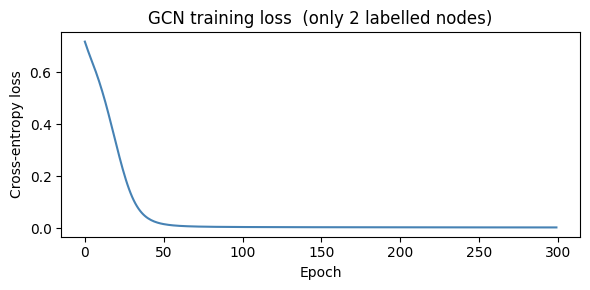

In [10]:
model     = GCN(in_features=n, hidden=16, num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

losses = []
for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    logits = model(X, A_hat_norm_kc)                          # (34, 2)
    loss   = F.cross_entropy(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(6, 3))
plt.plot(losses, color='steelblue')
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
plt.title("GCN training loss  (only 2 labelled nodes)")
plt.tight_layout(); plt.show()

Accuracy on all 34 nodes: 97.1%


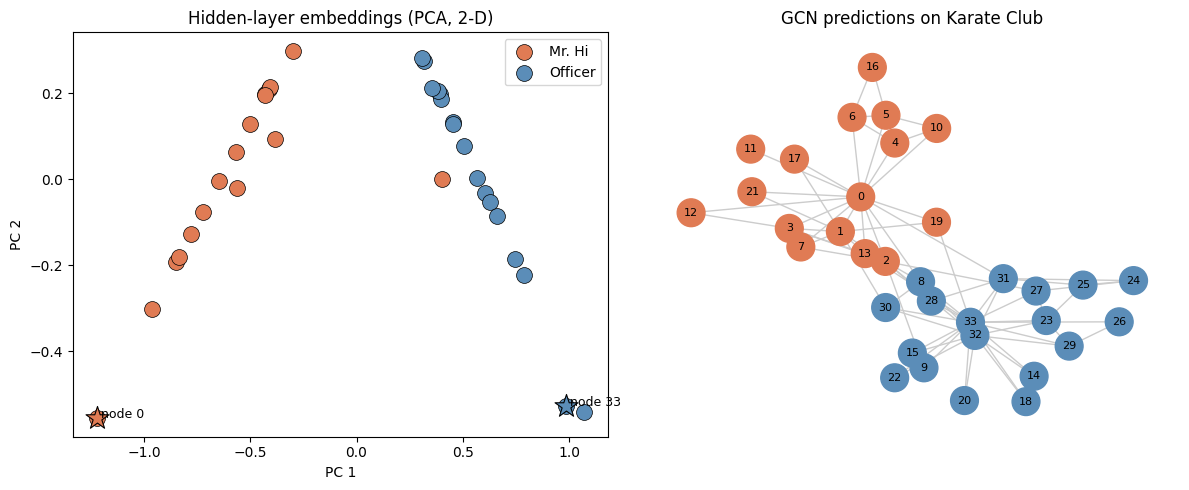

In [11]:
# ── Evaluate ──────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    logits = model(X, A_hat_norm_kc)
    preds  = logits.argmax(dim=1)
    embeds = model.embed(X, A_hat_norm_kc).numpy()   # (34, 16)

acc = (preds == y).float().mean().item()
print(f"Accuracy on all 34 nodes: {acc:.1%}")

# ── PCA: project 16-D embeddings to 2-D ───────────────────────────────────
H_c    = embeds - embeds.mean(0)
_, _, Vt = np.linalg.svd(H_c, full_matrices=False)
coords = H_c @ Vt[:2].T                             # (34, 2)

palette = ['#E07B54', '#5B8DB8']
labels_str = ['Mr. Hi', 'Officer']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: embedding scatter
for cls in [0, 1]:
    mask = (y == cls).numpy()
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    c=palette[cls], s=130, label=labels_str[cls],
                    edgecolors='k', linewidths=0.5)
for idx in [0, 33]:           # mark labelled nodes
    axes[0].scatter(coords[idx, 0], coords[idx, 1],
                    c=palette[y[idx].item()], s=300, marker='*',
                    edgecolors='k', linewidths=0.8)
    axes[0].annotate(f" node {idx}", (coords[idx, 0], coords[idx, 1]), fontsize=9)

axes[0].set_title("Hidden-layer embeddings (PCA, 2-D)")
axes[0].legend(); axes[0].set_xlabel("PC 1"); axes[0].set_ylabel("PC 2")

# Right: graph coloured by GCN prediction
pred_colors = [palette[p.item()] for p in preds]
nx.draw_networkx(G, pos=pos, node_color=pred_colors, node_size=400,
                 font_size=8, edge_color='#cccccc', ax=axes[1], with_labels=True)
axes[1].set_title("GCN predictions on Karate Club")
axes[1].axis('off')

plt.tight_layout(); plt.show()

---
## §5 — Other Prediction Tasks

The same `GCNLayer` building block and the same learnt node embeddings
can be adapted for three types of tasks (lecture P27):

| Task | Prediction level | Recipe |
|---|---|---|
| **Node classification** | per node | softmax over node embeddings |
| **Graph classification** | per graph | readout (mean/sum) → MLP |
| **Link prediction** | per edge pair | dot product of endpoint embeddings |

### 5.1 Graph Classification

**Global readout:** collapse all node embeddings into a single graph-level vector.

$$h_{\mathcal{G}} = \frac{1}{N}\sum_{i=1}^{N} h_i \quad (\text{mean pooling})$$

Then feed $h_{\mathcal{G}}$ into a linear classifier.

**Demo:** distinguish two types of synthetic graphs:
- **Class 0** — Erdős–Rényi random graphs (uniform random edges, $p=0.15$)
- **Class 1** — Barabási–Albert scale-free graphs (preferential attachment, $m=2$)

In [12]:
import random
random.seed(0)

def make_dataset(n_graphs=40, n_nodes=20, seed=0):
    rng = np.random.default_rng(seed)
    graphs, labels = [], []
    for _ in range(n_graphs // 2):
        graphs.append(nx.erdos_renyi_graph(n_nodes, 0.15,
                                           seed=int(rng.integers(1_000_000))))
        labels.append(0)
        graphs.append(nx.barabasi_albert_graph(n_nodes, 2,
                                               seed=int(rng.integers(1_000_000))))
        labels.append(1)
    return graphs, labels

train_graphs, train_labels = make_dataset(n_graphs=60, seed=0)
test_graphs,  test_labels  = make_dataset(n_graphs=20, seed=99)

def graph_to_tensors(G_nx):
    A_g = nx.to_numpy_array(G_nx)
    n_g = G_nx.number_of_nodes()
    X_g = torch.eye(n_g, dtype=torch.float32)
    return X_g, build_A_hat_norm(A_g)


class GraphGCN(nn.Module):
    """GCN + mean readout for graph classification."""

    def __init__(self, in_f, hidden, num_classes):
        super().__init__()
        self.gcn = GCNLayer(in_f, hidden)
        self.clf = nn.Linear(hidden, num_classes)

    def forward(self, X_g, A_g_norm):
        H  = self.gcn(X_g, A_g_norm)      # (N, hidden)
        hG = H.mean(dim=0)                 # (hidden,)  ← mean pooling
        return self.clf(hG)                # (num_classes,)


n_nodes     = 20
graph_model = GraphGCN(n_nodes, 32, 2)
g_opt       = torch.optim.Adam(graph_model.parameters(), lr=0.01)

# Training loop — iterate over graphs one by one (no batching needed for demo)
for epoch in range(60):
    graph_model.train()
    total_loss = 0.0
    for G_nx, lbl in zip(train_graphs, train_labels):
        X_g, A_g = graph_to_tensors(G_nx)
        g_opt.zero_grad()
        logit = graph_model(X_g, A_g).unsqueeze(0)       # (1, 2)
        loss  = F.cross_entropy(logit, torch.tensor([lbl]))
        loss.backward()
        g_opt.step()
        total_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}  avg loss: {total_loss/len(train_graphs):.4f}")

# Evaluation
graph_model.eval()
correct = 0
with torch.no_grad():
    for G_nx, lbl in zip(test_graphs, test_labels):
        X_g, A_g = graph_to_tensors(G_nx)
        pred = graph_model(X_g, A_g).argmax().item()
        correct += int(pred == lbl)
print(f"\nGraph classification accuracy: {correct}/{len(test_graphs)} = {correct/len(test_graphs):.1%}")

Epoch  20  avg loss: 0.0217
Epoch  40  avg loss: 0.0036
Epoch  60  avg loss: 0.0012

Graph classification accuracy: 20/20 = 100.0%


### 5.2 Link Prediction

**Task:** predict whether an edge exists between two nodes.

**Recipe:** score a node pair $(i, j)$ using the dot product of their embeddings:

$$\text{score}(i,j) = h_i \cdot h_j$$

High score → edge likely; low score → no edge.

We reuse the node embeddings from the Karate Club GCN trained in §4:
hold out 10 % of edges and check whether real edges score higher than
random non-edges.

Held-out positive edges : 7
Mean score  (real edges): 0.8474
Mean score  (non-edges) : 0.3807
Pairwise AUC            : 0.816  (random baseline = 0.5)


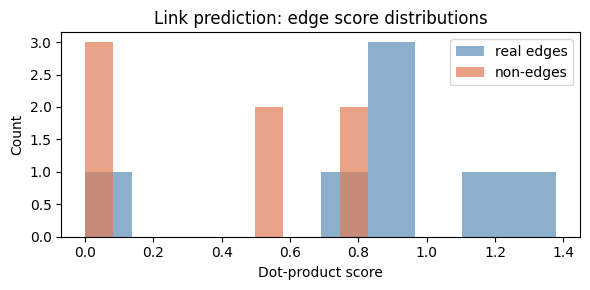

In [13]:
import random as _random
_random.seed(42)

all_edges = list(G.edges())
_random.shuffle(all_edges)
n_test    = max(1, len(all_edges) // 10)

test_pos_edges  = all_edges[:n_test]          # held-out positive (real) edges
train_edges_lp  = all_edges[n_test:]

# Build a pruned graph (without held-out edges) and retrain GCN
G_pruned  = nx.Graph()
G_pruned.add_nodes_from(G.nodes())
G_pruned.add_edges_from(train_edges_lp)
A_pruned  = nx.to_numpy_array(G_pruned)
A_pruned_norm = build_A_hat_norm(A_pruned)

lp_model = GCN(in_features=n, hidden=16, num_classes=2)
lp_opt   = torch.optim.Adam(lp_model.parameters(), lr=0.01, weight_decay=5e-4)
for _ in range(300):
    lp_model.train()
    lp_opt.zero_grad()
    logits = lp_model(X, A_pruned_norm)
    loss   = F.cross_entropy(logits[train_mask], y[train_mask])
    loss.backward()
    lp_opt.step()

# Extract embeddings
emb_lp = lp_model.embed(X, A_pruned_norm)   # (34, 16)

def edge_score(u, v):
    return (emb_lp[u] @ emb_lp[v]).item()

# Sample an equal number of non-edges (negative examples)
non_edges = list(nx.non_edges(G))
_random.shuffle(non_edges)
test_neg_edges = non_edges[:n_test]

pos_scores = [edge_score(u, v) for u, v in test_pos_edges]
neg_scores = [edge_score(u, v) for u, v in test_neg_edges]

print(f"Held-out positive edges : {n_test}")
print(f"Mean score  (real edges): {np.mean(pos_scores):.4f}")
print(f"Mean score  (non-edges) : {np.mean(neg_scores):.4f}")

# Pairwise ranking AUC
from itertools import product as _product
correct_pairs = sum(ps > ns for ps, ns in _product(pos_scores, neg_scores))
auc = correct_pairs / (len(pos_scores) * len(neg_scores))
print(f"Pairwise AUC            : {auc:.3f}  (random baseline = 0.5)")

# Visualise score distributions
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pos_scores, bins=10, alpha=0.7, color='#5B8DB8', label='real edges')
ax.hist(neg_scores, bins=10, alpha=0.7, color='#E07B54', label='non-edges')
ax.set_xlabel("Dot-product score"); ax.set_ylabel("Count")
ax.set_title("Link prediction: edge score distributions")
ax.legend()
plt.tight_layout(); plt.show()

---
## Summary

| Section | Key concept |
|---|---|
| **§1** | Graph → adjacency matrix $A$, degree matrix $D$, self-loops $\hat{A}=A+I$ |
| **§2** | GCN propagation rule: $H^{(l+1)} = \sigma(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}H^{(l)}W^{(l)})$; symmetric normalisation damps high-degree neighbours |
| **§3** | `GCNLayer`: `nn.Parameter` weight, manual forward (`A_norm @ H @ W`), autograd backward |
| **§4** | 2-layer GCN on Karate Club — only **2 labelled nodes**, label propagates through graph structure |
| **§5** | Same embeddings → graph classification (mean pooling + MLP) and link prediction (dot product) |

**Take-aways:**
- GCN = repeated neighbourhood averaging + learnable linear transform.
- Semi-supervised power: graph structure lets information flow from labelled to unlabelled nodes.
- The same `GCNLayer` block supports node-level, graph-level, and edge-level tasks.

---
## 6. Claude Code & MCP (Model Context Protocol)

> **Course Note:** Sections 6–11 across these weekly notebooks form a progressive series on using Claude Code as a deep-learning research assistant. This week we cover **MCP (Model Context Protocol)** — the mechanism that gives Claude Code access to the outside world.

---

### 6.1 What Is MCP?

**Model Context Protocol (MCP)** is an open standard for connecting AI applications to external systems. The official analogy is a good one:

> *"MCP is like USB-C for AI applications."*
> Just as USB-C provides a single standardised port to connect any peripheral device, MCP provides a single standardised protocol to connect any AI application to any external tool or data source.

**The problem MCP solves:**

Before MCP, every AI application needed custom, one-off integrations for each external tool. A different connector for GitHub, another for Notion, another for a database — none of them compatible. MCP replaces that fragmented landscape with one universal protocol.

**What MCP enables:**
- Claude Code can read and write files on your filesystem with proper access controls
- Claude Code can query a PostgreSQL database using natural language
- Claude Code can search GitHub issues and create pull requests on your behalf
- Claude Code can browse the web for up-to-date documentation
- Claude Code can post a Slack message or retrieve Notion pages

```
┌─────────────────────────────────────────────────────────┐
│                   Claude Code (MCP Client)              │
└──────────────────────┬──────────────────────────────────┘
           MCP Protocol│ (JSON-RPC over HTTP / stdio)
    ┌──────────────────┼──────────────────────────┐
    ▼                  ▼                          ▼
┌────────┐       ┌──────────┐             ┌──────────────┐
│ GitHub │       │PostgreSQL│             │  Filesystem  │
│  MCP   │       │   MCP    │    ...      │    MCP       │
│ Server │       │  Server  │             │   Server     │
└────────┘       └──────────┘             └──────────────┘
```

**MCP is currently the most actively expanding part of the Claude Code ecosystem.** New servers are added to the official registry every week.

### 6.2 MCP vs. Skills — Two Complementary Mechanisms

A common point of confusion is how MCP relates to the Skills we covered in Week 5. The key distinction is:

> **MCP is how Claude Code *gets* information and capabilities from the outside world.**
> **Skills are how Claude Code *handles* and *processes* information for your project.**

Think of it this way: Skills teach Claude *your workflow* — how you like code structured, what experiments to run, what format to use for reports. MCP gives Claude *new senses and tools* — the ability to look at a GitHub issue, query a database, or browse a website.

| Dimension | MCP | Skills |
|-----------|-----|--------|
| **Core purpose** | Connect to external systems (data & actions) | Customise Claude's behaviour for your project |
| **What it provides** | New tools (actions), resources (data), prompts (templates) | Instructions, workflow automation, project context |
| **Where it lives** | `.mcp.json` or `~/.claude.json` — server config | `.claude/skills/<name>/SKILL.md` — markdown instructions |
| **Execution** | Communicates with an external server process via JSON-RPC | Runs entirely inside Claude Code's context window |
| **Analogy** | External sensors and actuators | The agent's internal training and working memory |
| **Example** | Query a live PostgreSQL database for row counts | Automatically format results as a LaTeX table for your paper |
| **Context scope** | Fetches fresh data on each invocation | Can reference full conversation history |

**They work together.** A typical deep-learning research workflow might:
1. Use the **Filesystem MCP** to read raw experiment logs (MCP fetches the data)
2. Invoke a custom `/summarise-run` **Skill** to parse and structure the results (Skill processes the data)
3. Use the **GitHub MCP** to open a pull request with the summary (MCP takes an action)

Neither replaces the other — MCP expands what Claude *can reach*, Skills shape *how it behaves*.

### 6.3 What an MCP Server Provides

Every MCP server exposes up to three types of capability. Understanding these three primitives makes it easy to predict what any given server can do.

#### Tools — Executable Actions

Tools are functions the server exposes that Claude can call. When you ask Claude to "create a GitHub issue" or "query the database for rows where loss < 0.1", it is calling a **tool** on an MCP server.

Each tool has:
- A **name** (e.g., `create_issue`, `query_database`)
- A **description** Claude reads to decide when to invoke it
- An **input schema** specifying what parameters to pass

Tools are invoked **automatically** — Claude decides on its own when a tool is the right way to answer your request. You do not have to explicitly say "use the GitHub MCP tool".

#### Resources — Data Sources

Resources are read-only data items the server can expose. You reference them using `@server:protocol://path` syntax, or Claude fetches them automatically when relevant.

Examples:
- `@github:issue://456` — full text and metadata of GitHub issue #456
- `@postgres:schema://public` — schema of the public database schema
- `@filesystem:file:///home/user/project/results.csv` — a local file served securely

#### Prompts — Reusable Templates

Prompts are workflow templates a server ships alongside its tools. They appear in Claude Code as `/mcp__<server>__<prompt>` slash commands.

```
/mcp__github__pr_review 123          # template for reviewing PR #123
/mcp__db__query_builder              # guided SQL query builder
```

| Primitive | What it does | How you invoke it | Example |
|-----------|-------------|-------------------|---------|
| **Tool** | Performs an action or computation | Auto-invoked by Claude on request | `create_issue`, `run_query` |
| **Resource** | Provides read-only data or context | `@server:protocol://path` | `@github:issue://456` |
| **Prompt** | Pre-packaged workflow template | `/mcp__server__prompt_name` | `/mcp__github__pr_review` |

### 6.4 How to Use MCP in Claude Code

#### Adding an MCP Server

The core command is:

```bash
claude mcp add --transport <type> <name> <connection-params>
```

There are two common transport types:

**HTTP (remote server — most common for third-party services):**
```bash
claude mcp add --transport http github https://api.githubcopilot.com/mcp/
claude mcp add --transport http sentry https://mcp.sentry.dev/mcp
claude mcp add --transport http notion https://mcp.notion.com/mcp
```

**Stdio (local process — for servers that run on your machine):**
```bash
# Note: double-dash separates Claude's flags from the server command
claude mcp add --transport stdio filesystem -- npx -y @modelcontextprotocol/server-filesystem /home/user/project
claude mcp add --transport stdio --env AIRTABLE_API_KEY=mykey airtable -- npx -y airtable-mcp-server
```

#### Scopes — Who Can See This Server?

Every MCP server is registered at one of three scopes:

| Scope | Config file | Visibility | When to use |
|-------|-------------|------------|-------------|
| `local` (default) | `~/.claude.json` under project path | Only you, only in this project | Personal servers, secrets, experimental |
| `project` | `.mcp.json` in project root (commit to git) | Entire team | Shared team tools |
| `user` | `~/.claude.json` in home dir | You, across all projects | Personal utilities you use everywhere |

```bash
# Explicitly set scope
claude mcp add --transport http --scope project paypal https://mcp.paypal.com/mcp
claude mcp add --transport http --scope user hubspot  https://mcp.hubspot.com/anthropic
```

#### Managing Installed Servers

```bash
claude mcp list            # list all configured servers
claude mcp get github      # inspect a specific server
claude mcp remove github   # remove a server
```

#### Invoking MCP Inside Claude Code

Once a server is added, you don't need special syntax for tools — Claude calls them automatically:

```
> Summarise all open issues labelled "bug" in my repository
# Claude automatically calls the GitHub MCP list_issues tool

> What tables exist in the production database?
# Claude automatically calls the PostgreSQL MCP list_tables tool
```

For resources and prompts, use the explicit syntax:
```
> Analyse @github:issue://789 and suggest a fix
> /mcp__github__pr_review 42
```

Check server status at any time inside Claude Code with `/mcp`.

### 6.5 Popular MCP Servers and What They Do

The official MCP registry at [registry.modelcontextprotocol.io](https://registry.modelcontextprotocol.io) lists hundreds of servers. Below are the most widely used, grouped by category.

#### Developer Tools

| Server | What it does | Example prompts |
|--------|-------------|----------------|
| **GitHub** | Manage repositories, list/create issues and PRs, review code, search commits | *"Open an issue for the failing test in train.py"*; *"List all PRs mentioning 'dropout'"* |
| **Git** (local) | Read local git history, diff, branch, commit | *"Summarise what changed in the last 10 commits"* |
| **Sentry** | Browse error reports, stack traces, crash analytics | *"What are the top 5 errors in production this week?"* |

#### Data & Databases

| Server | What it does | Example prompts |
|--------|-------------|----------------|
| **Filesystem** (local) | Secure read/write access to local files and directories | *"Read all `.log` files under `runs/` and show me validation losses"* |
| **PostgreSQL / DBHub** (local) | Natural-language queries against any SQL database | *"How many training samples have label == 3?"* |
| **Memory** (local) | Persistent knowledge graph that survives across Claude Code sessions | *"Remember that we use AdamW with lr=1e-3 for all experiments"* |

#### Web & Research

| Server | What it does | Example prompts |
|--------|-------------|----------------|
| **Web Fetch** | Retrieve and parse any web page | *"Fetch the PyTorch docs for `nn.MultiheadAttention` and summarise the parameters"* |
| **Brave Search** | Live internet search with cited results | *"Find the latest papers on graph transformers published in 2025"* |

#### Productivity & Communication

| Server | What it does | Example prompts |
|--------|-------------|----------------|
| **Slack** | Send messages, search channels, summarise threads | *"Post a summary of today's experiment results to #ml-research"* |
| **Notion** | Read and write Notion databases and pages | *"Add a new row to our Results database with the F1 score from this run"* |
| **Airtable** | Query and update Airtable bases | *"Update the Status column to 'Done' for Experiment #42"* |

#### For Deep Learning Research Specifically

The combination most useful for this course:

```
Filesystem MCP   →  read raw experiment outputs, CSVs, checkpoints
GitHub MCP       →  track issues, submit code reviews, log results as comments
Web Fetch MCP    →  pull up paper abstracts and PyTorch documentation on demand
Memory MCP       →  persist hyperparameter decisions and experiment notes across sessions
```

> **Security note:** MCP servers that fetch untrusted external content (web pages, third-party APIs) can expose you to **prompt injection** — adversarially crafted content designed to hijack Claude's behaviour. Always use well-known, reputable servers for production work, and review the output of any external fetch before acting on it.

In [ ]:
# ============================================================
# MCP Quick-Reference — run these in your terminal, not here
# ============================================================

# --- ADDING MCP SERVERS ---

# Add a remote HTTP server (most third-party services)
# claude mcp add --transport http github https://api.githubcopilot.com/mcp/
# claude mcp add --transport http sentry  https://mcp.sentry.dev/mcp
# claude mcp add --transport http notion  https://mcp.notion.com/mcp

# Add a local stdio server (runs as a process on your machine)
# claude mcp add --transport stdio filesystem -- \
#     npx -y @modelcontextprotocol/server-filesystem /path/to/project

# Add with environment variable (for API key auth)
# claude mcp add --transport stdio \
#     --env AIRTABLE_API_KEY=YOUR_KEY \
#     airtable -- npx -y airtable-mcp-server

# Add at project scope (shared with team via .mcp.json)
# claude mcp add --transport http --scope project sentry https://mcp.sentry.dev/mcp

# --- MANAGING SERVERS ---
# claude mcp list              # see all registered servers
# claude mcp get github        # inspect a specific server config
# claude mcp remove github     # deregister a server

# --- INSIDE CLAUDE CODE ---
# /mcp                         # view connected servers & authenticate

# Invoke a resource by reference:
# > Analyse @github:issue://789 and suggest a fix

# Invoke a prompt template:
# > /mcp__github__pr_review 42

# Everything else: just describe what you want —
# Claude will call the appropriate MCP tool automatically.
#
# Example natural-language invocations:
# > "Read the validation loss from runs/exp01/metrics.csv and plot it"
# > "What are the top bugs in my Sentry project this week?"
# > "Commit my changes with a descriptive message"
# > "Search the web for the ViT paper and give me a one-paragraph summary"

print("MCP quick-reference loaded — see comments above for terminal commands.")